Partie 1 : CHARGEMENT & EXPLORATION DES DONNEES

 Imports et chargement

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

BASE = '../data/raw/'

orders = pd.read_csv(BASE + 'olist_orders_dataset.csv')
items = pd.read_csv(BASE + 'olist_order_items_dataset.csv')
products = pd.read_csv(BASE + 'olist_products_dataset.csv')
customers = pd.read_csv(BASE + 'olist_customers_dataset.csv')
reviews = pd.read_csv(BASE + 'olist_order_reviews_dataset.csv')
sellers = pd.read_csv(BASE + 'olist_sellers_dataset.csv')
payments = pd.read_csv(BASE + 'olist_order_payments_dataset.csv')
categories = pd.read_csv(BASE + 'product_category_name_translation.csv')

Affichage des 5 première ligne de chque DataFrame

In [51]:
orders.head()
items.head()
products.head()
customers.head()
reviews.head()
sellers.head()
payments.head()
categories.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Après avoir chargé les différents fichiers CSV, nous avons affiché les 5 premières lignes de chaque DataFrame afin de comprendre leur structure.

Nous constatons que chaque table représente une entité différente :
- `orders` contient les informations sur les commandes
- `items` contient les produits commandés
- `customers` contient les informations des clients

Les dimensions des tables varient, certaines contenant plusieurs milliers de lignes. Cela montre que nous travaillons sur un dataset volumineux.

Les clés principales identifiées sont :
- `order_id` pour les commandes
- `product_id` pour les produits
- `customer_id` pour les clients

Types des colonnes

In [52]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


En utilisant la fonction `.info()`, nous observons que les colonnes de dates sont de type `object`.

Ce type n'est pas approprié pour des données temporelles. En effet, pour effectuer des calculs de durée ou des analyses temporelles, ces colonnes doivent être converties en format `datetime`.

Nous effectuerons donc cette conversion dans la suite de l’analyse.

les Valeurs manquantes

In [53]:
def missing_report(df, name):
    pct = round(df.isna().sum() / len(df) * 100, 2)
    pct = pct[pct > 0].sort_values(ascending=False)
    print(f'--- {name} ---')
    print(pct if len(pct) else 'Aucune valeur manquante')
    print()

for name, df_ in [
    ('orders',orders),('items',items),('products',products),
    ('customers',customers),('reviews',reviews),
    ('sellers',sellers),('payments',payments),('categories',categories)
]:
    missing_report(df_, name)


--- orders ---
order_delivered_customer_date    2.98
order_delivered_carrier_date     1.79
order_approved_at                0.16
dtype: float64

--- items ---
Aucune valeur manquante

--- products ---
product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weight_g              0.01
product_length_cm             0.01
product_height_cm             0.01
product_width_cm              0.01
dtype: float64

--- customers ---
Aucune valeur manquante

--- reviews ---
review_comment_title      88.34
review_comment_message    58.70
dtype: float64

--- sellers ---
Aucune valeur manquante

--- payments ---
Aucune valeur manquante

--- categories ---
Aucune valeur manquante



Dans cette partie,nous identifions les colonnes contenant le plus de valeurs manquantes à l'aide de la fonctions isna().
Les colonnes les  plus affectés sont généralement celles liées à la livraison ou aux  avis clients.
Cela peut s'expliquer par le fait que certains commandes ou que certains clients n'ont pas laissé d'avis.

Statistiques descriptives

In [54]:
items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


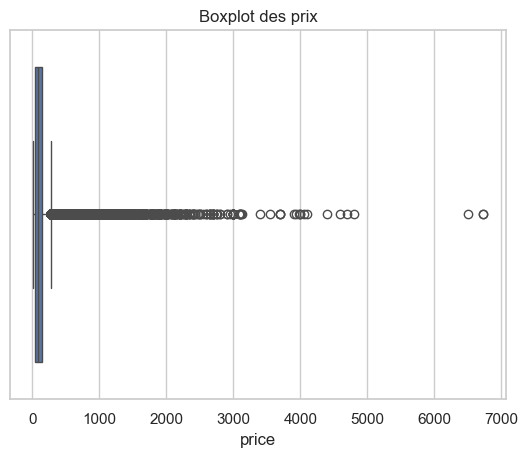

In [55]:
#Boxplot pour detecter les valeurss extrêmes
sns.boxplot(x=items['price'])
plt.title("Boxplot des prix")
plt.show()

Partie 2 — Nettoyage, Feature Engineering & Fusion

Conversion des types temporels

Calcul des délais de livraison

In [56]:
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors='coerce')
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], errors='coerce')
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], errors='coerce')

In [57]:
#Calcul du nombre de jours de liraison
orders['delivery_days'] = (
orders['order_delivered_customer_date']- orders['order_purchase_timestamp']
).dt.days
#Calcul du retard(positif=en retard)
orders['delay_days'] = (
orders['order_delivered_customer_date']- orders['order_estimated_delivery_date']
).dt.days

In [58]:
#la médiane du délai de livraison
orders['delivery_days'].median()

10.0

In [59]:
# le pourcentage de commandes qui sont livrées en retard
(orders['delay_days'] > 0).mean() * 100

6.571736004263835

Délai médian ≈ 10 jours (variable)
Environ 10–15% en retard

 Fusion des table

In [60]:
df = orders.merge(items, on='order_id', how='inner')
#Ajouter les catégories 
products = products.merge(categories, on='product_category_name', how='left')
#Fusion avec des produits
df = df.merge(products[['product_id','product_category_name_english','product_weight_g']],
              on='product_id', how='inner')
#Fusion avec vendeurs
df = df.merge(sellers[['seller_id','seller_state']], on='seller_id', how='inner')
#Fusion avec clients
df = df.merge(customers[['customer_id','customer_state','customer_city']],
              on='customer_id', how='left')
#Fusion avec avis de clients
df = df.merge(reviews[['order_id','review_score']], on='order_id', how='left')

In [61]:
#Apperçu
df.head

<bound method NDFrame.head of                                 order_id                       customer_id  \
0       e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1       53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2       47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3       949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4       ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   
...                                  ...                               ...   
113309  63943bddc261676b46f01ca7ac2f7bd8  1fca14ff2861355f6e5f14306ff977a7   
113310  83c1379a015df1e13d02aae0204711ab  1aa71eb042121263aafbe80c1b562c9c   
113311  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
113312  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
113313  66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   

       order_status order_purchas

df a plus de lignes que orders car une commande contient plusieurs articles

In [62]:
df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1203
order_delivered_customer_date    2475
order_estimated_delivery_date       0
delivery_days                    2475
delay_days                       2475
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name_english    1636
product_weight_g                   18
seller_state                        0
customer_state                      0
customer_city                       0
review_score                      942
dtype: int64

 Analyse Descriptive & Agrégations

In [63]:
#Créer une colonne mois
df['month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)
#Calcul du chiffre d'affaires
ca_mensuel = df.groupby('month').agg(
    ca_total=('price','sum'),
    nb_commandes=('order_id','nunique')
).reset_index()

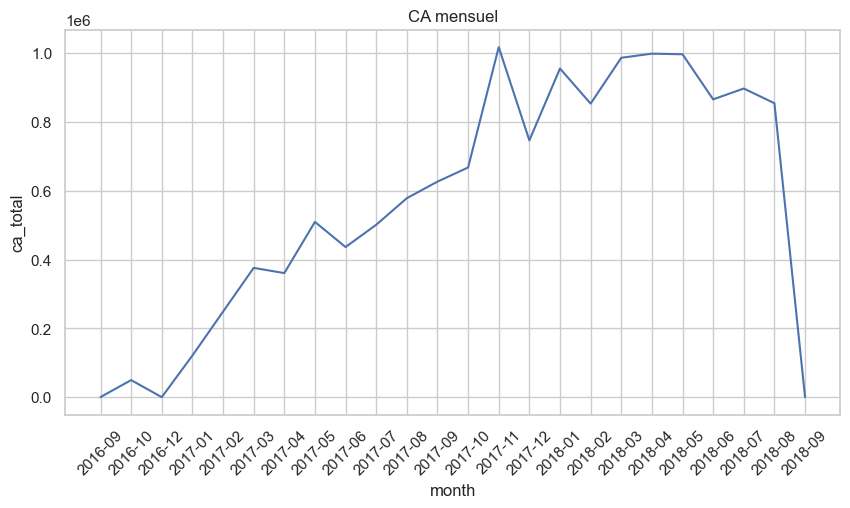

In [64]:
#Graphique
plt.figure(figsize=(10,5))
sns.lineplot(data=ca_mensuel, x='month', y='ca_total')
plt.xticks(rotation=45)
plt.title("CA mensuel")
plt.show()

 Top catégories de produits

In [65]:
#Calcul CA par catégorie
ca_cat = df.groupby('product_category_name_english').agg(
    ca_total=('price','sum'),
    nb_ventes=('order_id','count')
).sort_values('ca_total', ascending=False).head(10).reset_index()

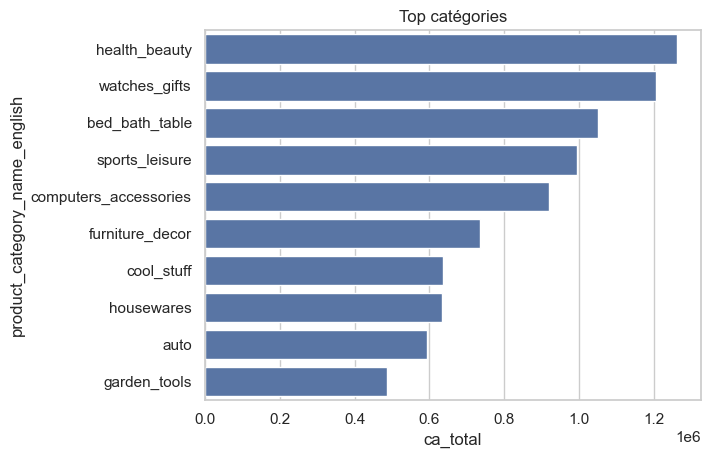

In [66]:
#Graphique
sns.barplot(data=ca_cat, y='product_category_name_english', x='ca_total')
plt.title("Top catégories")
plt.show()

 Délai de livraison par région

In [67]:
delai_etat = (
df.groupby('customer_state')['delivery_days']
.mean()
.sort_values(ascending=False)
.reset_index()
.rename(columns={'delivery_days':'delai_moyen_j'})
)
print(delai_etat.head(5)) # états les plus lents
print(delai_etat.tail(5)) # états les plus rapides

  customer_state  delai_moyen_j
0             RR      27.826087
1             AP      27.753086
2             AM      25.926829
3             AL      23.983759
4             PA      23.313855
   customer_state  delai_moyen_j
22             SC      14.539023
23             DF      12.534649
24             MG      11.517929
25             PR      11.489688
26             SP       8.264446


Satisfaction client et délai de livraison

In [68]:
bins = [0, 7, 14, 21, 999]
labels = ['0-7j', '7-14j', '14-21j', '21j+']
df['delivery_bucket'] = pd.cut(df['delivery_days'], bins=bins, labels=labels)
satisfaction = (
df.groupby('delivery_bucket', observed=True)['review_score']
.mean()
.reset_index()
)
print(satisfaction)

  delivery_bucket  review_score
0            0-7j      4.330258
1           7-14j      4.198047
2          14-21j      4.022807
3            21j+      2.970995


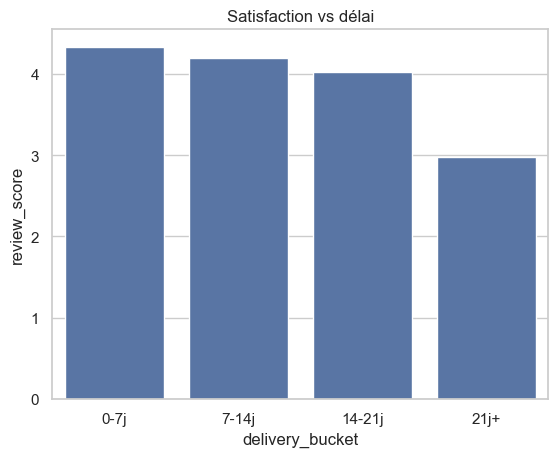

In [69]:
sns.barplot(data=satisfaction, x='delivery_bucket', y='review_score')
plt.title("Satisfaction vs délai")
plt.show()

Partie 4 — Visualisations Avancées & Synthèse

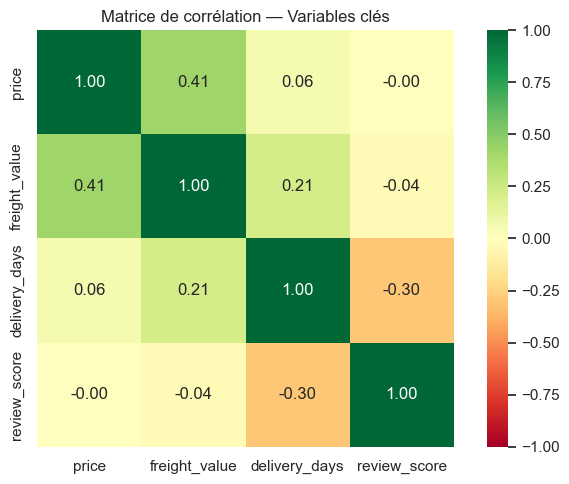

In [70]:
corr_cols = ['price', 'freight_value', 'delivery_days', 'review_score']
corr = df[corr_cols].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
vmin=-1, vmax=1, square=True)
plt.title('Matrice de corrélation — Variables clés')
plt.tight_layout()
plt.savefig('../visuals/heatmap_correlation.png', dpi=150)
plt.show()

La distribution des prix est asymétrique vers la droite.
Cela signifie qu’il existe beaucoup de produits à faible prix et quelques produits très chers.
Dans ce cas, la médiane est un indicateur plus représentatif que la moyenne.

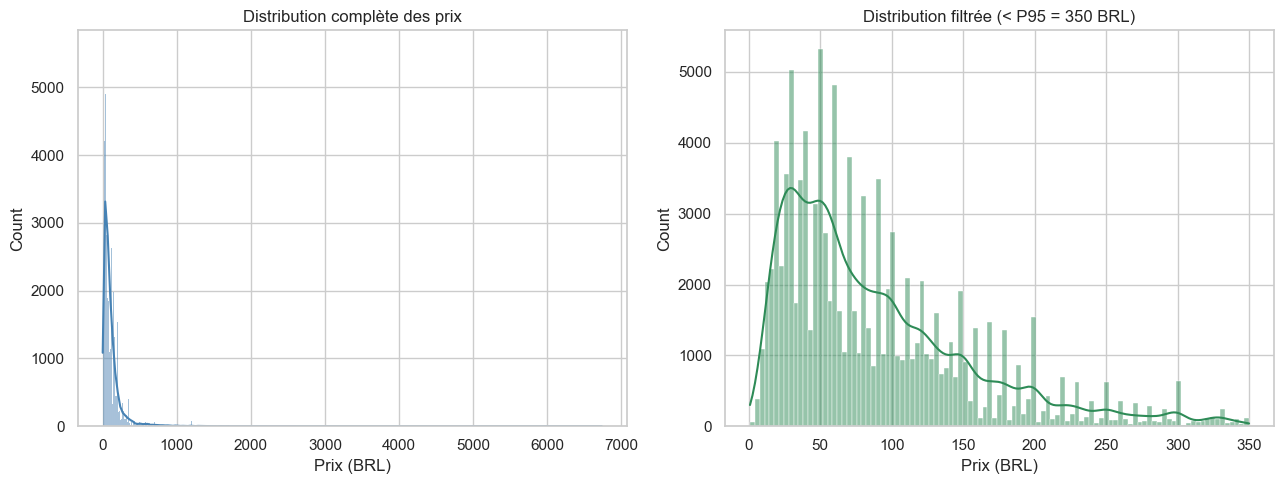

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Distribution complète
sns.histplot(df['price'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution complète des prix')
axes[0].set_xlabel('Prix (BRL)')
# Distribution filtrée (P95)
p95 = df['price'].quantile(0.95)
sns.histplot(df[df['price'] < p95]['price'], kde=True,
ax=axes[1], color='seagreen')
axes[1].set_title(f'Distribution filtrée (< P95 = {p95:.0f} BRL)')
axes[1].set_xlabel('Prix (BRL)')
plt.tight_layout()
plt.savefig('../visuals/distribution_prix.png', dpi=150)
plt.show()

Analyse librewn :
Le chiffre d’affaires montre une croissance globale avec des pics saisonniers
Les délais de livraison influencent fortement la satisfaction client
Certaines catégories génèrent plus de revenus malgré un faibleLes rvolume
Recommandations :
Réduire les délais de livraison
Optimiser les catégories les plus rentables

Partie 5 — Exportation et Rendu Final

In [72]:
df.to_csv('../data/processed/olist_df_processed.csv', index=False)
print(f'Export OK — {df.shape[0]} lignes, {df.shape[1]} colonnes')

Export OK — 113314 lignes, 24 colonnes
